In [1]:
import pymrio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Load the original EXIOBASE data
exio3 = pymrio.parse_exiobase3(
    path=r"C:\Users\Dyde-nairn\Documents\python\i_o_scenarios\IOT_2022_pxp.v3.9.6.zip"
)


In [3]:

# Compute Leontief inverse manually
exio3.L = pymrio.calc_L(exio3.A)


In [10]:
sector_list = exio3.A.columns.get_level_values(1).unique().tolist()
for sector in sector_list:
    print(sector)

Paddy rice
Wheat
Cereal grains nec
Vegetables, fruit, nuts
Oil seeds
Sugar cane, sugar beet
Plant-based fibers
Crops nec
Cattle
Pigs
Poultry
Meat animals nec
Animal products nec
Raw milk
Wool, silk-worm cocoons
Manure (conventional treatment)
Manure (biogas treatment)
Products of forestry, logging and related services (02)
Fish and other fishing products; services incidental of fishing (05)
Anthracite
Coking Coal
Other Bituminous Coal
Sub-Bituminous Coal
Patent Fuel
Lignite/Brown Coal
BKB/Peat Briquettes
Peat
Crude petroleum and services related to crude oil extraction, excluding surveying
Natural gas and services related to natural gas extraction, excluding surveying
Natural Gas Liquids
Other Hydrocarbons
Uranium and thorium ores (12)
Iron ores
Copper ores and concentrates
Nickel ores and concentrates
Aluminium ores and concentrates
Precious metal ores and concentrates
Lead, zinc and tin ores and concentrates
Other non-ferrous metal ores and concentrates
Stone
Sand and clay
Chemical a

In [5]:
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

In [11]:
# -----------------------------
# Step 2: Define sector and countries
# -----------------------------
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

# Pre-shock aluminium production by country
aluminium_production = exio3.x.loc[(slice(None), sector_name)]

# Dictionary to store impact results
impact_results = {}

# -----------------------------
# Step 3: Loop over countries and apply shock
# -----------------------------
for country in countries:
    # Copy original A matrix
    shocked_A = exio3.A.copy()

    # Apply 1% productivity shock to the column for (country, sector_name)
    shocked_A.loc[:, (country, sector_name)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101

    # Compute new Leontief inverse
    shocked_L = pymrio.calc_L(shocked_A)

    # Compute total output before and after shock
    original_output = exio3.L @ exio3.Y.sum(axis=1)
    shocked_output = shocked_L @ exio3.Y.sum(axis=1)

    # Impact on French wind energy
    impact_on_fr_wind = shocked_output.loc[("FR", "Electricity by wind")] - original_output.loc[("FR", "Electricity by wind")]

    # Store result
    impact_results[country] = impact_on_fr_wind

# -----------------------------
# Step 4: Create DataFrame for plotting
# -----------------------------
impact_df = pd.DataFrame({
    "Country": impact_results.keys(),
    "Impact on FR Wind": impact_results.values(),
    "Aluminium Production": aluminium_production.values
}).sort_values(by="Aluminium Production", ascending=False)

# -----------------------------
# Step 5: Plot results
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Aluminium production by country
axes[0].bar(impact_df["Country"], impact_df["Aluminium Production"], color="black")
axes[0].set_title("Aluminium Ore Production (Pre-Shock) by Region")
axes[0].set_ylabel("Aluminium Ore Production (Million EUR)")
axes[0].tick_params(axis='x', rotation=90)

# Plot 2: Impact on French wind energy
axes[1].bar(impact_df["Country"], impact_df["Impact on FR Wind"], color="blue")
axes[1].set_title("Impact on French Wind Energy Output by 1% Productivity Shock in Aluminium Ore")
axes[1].set_ylabel("Change in Output (Million EUR)")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("impact_aluminium_shock.png", dpi=300)


KeyError: 'Aluminium ores and concentrates'

In [13]:
# -----------------------------
# Step 2: Define sector and countries
# -----------------------------
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

# Pre-shock aluminium production by country
aluminium_production = exio3.x.loc[(slice(None), sector_name)]

# Dictionary to store impact results
impact_results = {}

# -----------------------------
# Step 3: Loop over countries and apply shock
# -----------------------------
for country in countries:
    # Copy original A matrix
    shocked_A = exio3.A.copy()

    # Apply 1% productivity shock to the column for (country, sector_name)
    shocked_A.loc[:, (country, sector_name)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101

    # Compute new Leontief inverse
    shocked_L = pymrio.calc_L(shocked_A)

    # Compute total output before and after shock
    original_output = exio3.L @ exio3.Y.sum(axis=1)
    shocked_output = shocked_L @ exio3.Y.sum(axis=1)

    # Impact on French wind energy
    impact_on_fr_wind = shocked_output.loc[("FR", "Electricity by wind")] - original_output.loc[("FR", "Electricity by wind")]

    # Store result
    impact_results[country] = impact_on_fr_wind

# -----------------------------
# Step 4: Create DataFrame for plotting
# -----------------------------
impact_df = pd.DataFrame({
    "Country": impact_results.keys(),
    "Impact on FR Wind": impact_results.values(),
    "Aluminium Production": aluminium_production.values
}).sort_values(by="Aluminium Production", ascending=False)

# -----------------------------
# Step 5: Plot results
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Aluminium production by country
axes[0].bar(impact_df["Country"], impact_df["Aluminium Production"], color="black")
axes[0].set_title("Aluminium Ore Production (Pre-Shock) by Region")
axes[0].set_ylabel("Aluminium Ore Production (Million EUR)")
axes[0].tick_params(axis='x', rotation=90)

# Plot 2: Impact on French wind energy
axes[1].bar(impact_df["Country"], impact_df["Impact on FR Wind"], color="blue")
axes[1].set_title("Impact on French Wind Energy Output by 1% Productivity Shock in Aluminium Ore")
axes[1].set_ylabel("Change in Output (Million EUR)")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("impact_aluminium_shock.png", dpi=300)
plt.show()

KeyError: 'Aluminium ores and concentrates'

In [14]:
print(exio3.x.loc[(slice(None), sector_name)].head())

KeyError: 'Aluminium ores and concentrates'

In [15]:
# Check the structure of A (technical coefficient matrix)
print("A shape:", exio3.A.shape)
print("A index levels:", exio3.A.index.names)
print("A columns levels:", exio3.A.columns.names)

# Check available sectors and countries
print("First 10 sectors:", exio3.A.columns.get_level_values(1).unique()[:10])
print("First 10 countries:", exio3.A.columns.get_level_values(0).unique()[:10])

# Check if 'Aluminium ores and concentrates' exists
print("'Aluminium ores and concentrates' in sectors?",
      "Aluminium ores and concentrates" in exio3.A.columns.get_level_values(1))

# Check if 'Electricity by wind' exists for France
print("'Electricity by wind' for FR exists?",
      ("FR", "Electricity by wind") in exio3.A.index)

# Check Y (final demand) structure
print("Y shape:", exio3.Y.shape)
print("Y index levels:", exio3.Y.index.names)
print("Y columns levels:", exio3.Y.columns.names)

# Check x (output vector) structure
print("x shape:", exio3.x.shape)
print("x index levels:", exio3.x.index.names)

A shape: (9800, 9800)
A index levels: ['region', 'sector']
A columns levels: ['region', 'sector']
First 10 sectors: Index(['Paddy rice', 'Wheat', 'Cereal grains nec', 'Vegetables, fruit, nuts',
       'Oil seeds', 'Sugar cane, sugar beet', 'Plant-based fibers',
       'Crops nec', 'Cattle', 'Pigs'],
      dtype='object', name='sector')
First 10 countries: Index(['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI'], dtype='object', name='region')
'Aluminium ores and concentrates' in sectors? True
'Electricity by wind' for FR exists? True
Y shape: (9800, 343)
Y index levels: ['region', 'sector']
Y columns levels: ['region', 'category']
x shape: (9800, 1)
x index levels: ['region', 'sector']


In [16]:
# Pick one country and sector
test_country = "AU"
test_sector = "Aluminium ores and concentrates"

# Copy original A matrix
shocked_A = exio3.A.copy()

# Apply 1% productivity shock to AU's aluminium ore sector
shocked_A.loc[:, (test_country, test_sector)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101

# Compute new Leontief inverse
shocked_L = pymrio.calc_L(shocked_A)

# Compute original and shocked outputs
original_output = exio3.L @ exio3.Y.sum(axis=1)
shocked_output = shocked_L @ exio3.Y.sum(axis=1)

# Calculate impact on French wind and solar
impact_wind = shocked_output.loc[("FR", "Electricity by wind")] - original_output.loc[("FR", "Electricity by wind")]
impact_solar = shocked_output.loc[("FR", "Electricity by solar")] - original_output.loc[("FR", "Electricity by solar")]

print(f"Impact on French wind energy (AU shock): {impact_wind}")
print(f"Impact on French solar energy (AU shock): {impact_solar}")

KeyError: ('FR', 'Electricity by solar')

In [18]:
# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# Original output for French wind energy
original_output = exio3.L @ exio3.Y.sum(axis=1)
original_fr_wind = original_output.loc[("FR", "Electricity by wind")]

# Apply 1% productivity shock to Aluminium ores and concentrates in Australia
country = "AU"
sector_name = "Aluminium ores and concentrates"

shocked_A = exio3.A.copy()
shocked_A.loc[:, (country, sector_name)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101

# Compute new Leontief inverse and shocked output
shocked_L = pymrio.calc_L(shocked_A)
shocked_output = shocked_L @ exio3.Y.sum(axis=1)
shocked_fr_wind = shocked_output.loc[("FR", "Electricity by wind")]

# Print impact
impact = shocked_fr_wind - original_fr_wind
print(f"Impact on French wind energy after 1% productivity shock in {sector_name} ({country}): {impact:.6f} EUR")

Impact on French wind energy after 1% productivity shock in Aluminium ores and concentrates (AU): 0.000010 EUR


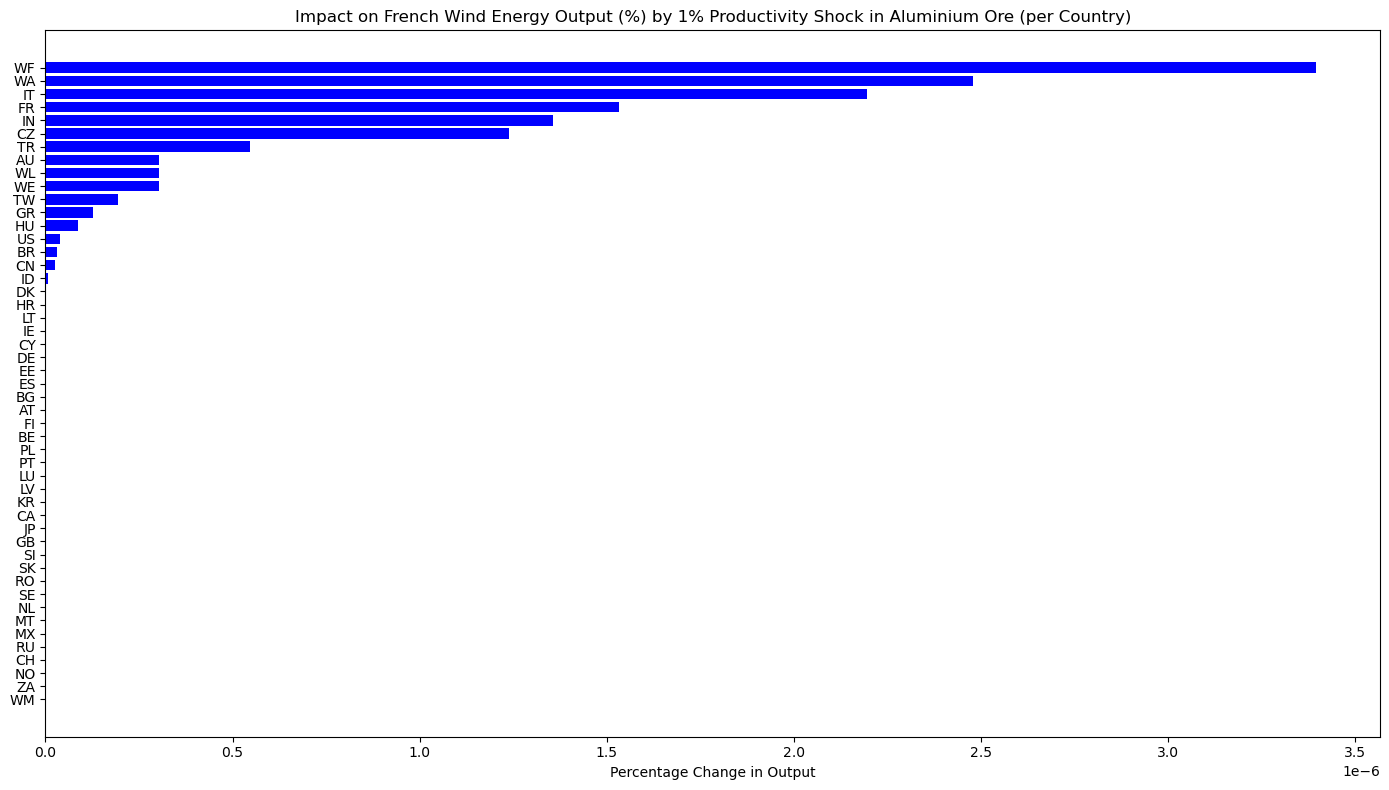

In [19]:

# Compute original Leontief inverse
exio3.L = pymrio.calc_L(exio3.A)

# -----------------------------
# Step 2: Original French wind output
# -----------------------------
original_output = exio3.L @ exio3.Y.sum(axis=1)
original_fr_wind = original_output.loc[("FR", "Electricity by wind")]

# -----------------------------
# Step 3: Define sector and countries
# -----------------------------
sector_name = "Aluminium ores and concentrates"
countries = exio3.A.columns.get_level_values(0).unique()

# Dictionary to store percentage impact results
impact_percent = {}

# -----------------------------
# Step 4: Loop over countries and apply shock
# -----------------------------
for country in countries:
    shocked_A = exio3.A.copy()
    shocked_A.loc[:, (country, sector_name)] *= 1 / (1 - 0.01)  # Scale column by ~1.0101
    shocked_L = pymrio.calc_L(shocked_A)
    shocked_output = shocked_L @ exio3.Y.sum(axis=1)
    shocked_fr_wind = shocked_output.loc[("FR", "Electricity by wind")]
    impact = shocked_fr_wind - original_fr_wind
    impact_percent[country] = (impact / original_fr_wind) * 100  # Convert to %

# -----------------------------
# Step 5: Create DataFrame and plot
# -----------------------------
impact_df = pd.DataFrame({
    "Country": list(impact_percent.keys()),
    "Impact (%)": list(impact_percent.values())
}).sort_values(by="Impact (%)", ascending=False)

# Plot the results
plt.figure(figsize=(14, 8))
plt.barh(impact_df["Country"], impact_df["Impact (%)"], color='blue')
plt.title("Impact on French Wind Energy Output (%) by 1% Productivity Shock in Aluminium Ore (per Country)")
plt.xlabel("Percentage Change in Output")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("impact_fr_wind_aluminium_ores_percent.png", dpi=300)
plt.show()


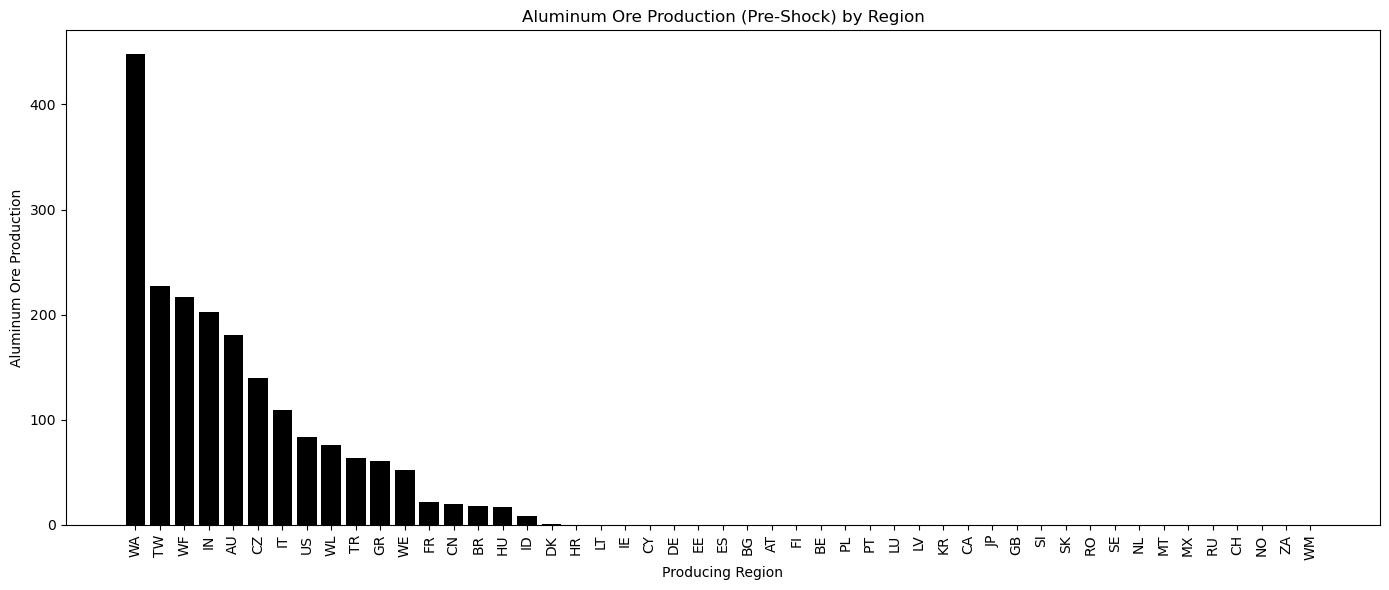

In [22]:
# Use IndexSlice for MultiIndex selection
idx = pd.IndexSlice
sector_name = "Aluminium ores and concentrates"

# Extract gross output for Aluminum Ore by country
aluminium_output = exio3.x.loc[idx[:, sector_name], :]
aluminium_output_df = aluminium_output.reset_index()
aluminium_output_df.columns = ["Country", "Sector", "Output"]

# Sort by output
aluminium_output_df = aluminium_output_df.sort_values(by="Output", ascending=False)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(aluminium_output_df["Country"], aluminium_output_df["Output"], color="black")
plt.title("Aluminum Ore Production (Pre-Shock) by Region")
plt.ylabel("Aluminum Ore Production")
plt.xlabel("Producing Region")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("aluminium_production_by_region.png", dpi=300)
plt.show()